CBIM Problem Canvas

Situation- A retail chain has 12 stores across Andhra Pradesh and sells five types of products: Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care. The Category Manager has a supplier meeting coming up and wants to understand how the categories and products are performing.

Complication- The Category Manager is not clear about which categories and products are doing well or not. She also wants to know whether discounts and sales patterns are helping the business.

Question- Which categories and products are doing well or declining, which products are affecting the performance, and what should the Category Manager focus on or question in the supplier meeting?

SSOT- The MUC01 Retail Sales Dataset will be the main source of data for this analysis.

Success Definition- The analysis will be successful if it clearly shows the category and product performance and helps the Category Manager take a clear, data-based decision in the supplier meeting.

Primary Stakeholder- Category Manager — she needs to understand category trends, product performance, discount results, sales patterns, and the main recommendation for the supplier meeting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
df.shape

(107836, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


In [5]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

In [6]:
df.describe()

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


In [7]:
df["category"].nunique()

5

In [8]:
df["product_name"].nunique()

25

In [9]:
df["transaction_id"].duplicated().sum()

np.int64(0)

Load and Inspect the Data

The dataset contains 107,836 transaction rows from January to June 2026, covering 5 product categories and 25 different products. This gives enough data to compare category and product performance over the six-month period.

There are no missing values or duplicate transaction IDs, so the dataset is complete for the available fields and can be used for the planned analysis.

The dataset also contains revenue, units sold, unit price and discount information, which will help us understand product performance and discount effectiveness.

Category Revenue Trend

I will compare the monthly revenue of all five product categories from January to June 2026. This will help us see which categories are growing, which are declining, and which are staying relatively stable over time.

In [10]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby(
    ["month", "category"]
)["revenue"].sum().reset_index()
monthly_revenue.head()

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81


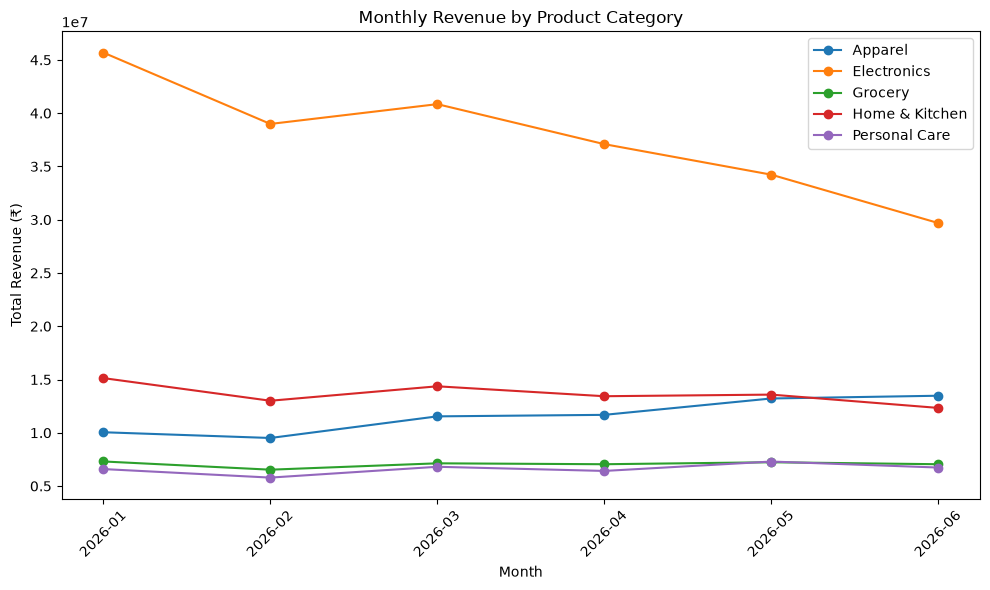

In [11]:
plt.figure(figsize=(10, 6))
for category in monthly_revenue["category"].unique():
    data = monthly_revenue[monthly_revenue["category"] == category]
    plt.plot(data["month"], data["revenue"], marker="o", label=category)
plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
category_change = monthly_revenue.pivot(
    index="month",
    columns="category",
    values="revenue"
)
decline = ((category_change.iloc[-1] - category_change.iloc[0])
           / category_change.iloc[0]) * 100
decline.sort_values()

category
Electronics      -35.020713
Home & Kitchen   -18.489275
Grocery           -3.548538
Personal Care      2.178118
Apparel           34.100144
dtype: float64

In [13]:
monthly_change = category_change.pct_change()
consistency = monthly_change.std().sort_values()
consistency

category
Grocery           0.072271
Electronics       0.076897
Home & Kitchen    0.095857
Apparel           0.106520
Personal Care     0.134975
dtype: float64

Business Insight

Electronics has the biggest decline in revenue. Its revenue dropped from ₹4.57 crore in January to ₹2.97 crore in June, which is around a 35% decrease. This is important to consider during the supplier review because sales have been going down, so its shelf space and promotional support may need to be reviewed.

Grocery is the most stable category. Its revenue changed by only about 3.55% from January to June, showing that sales have remained fairly steady over the six month period.

Top and Bottom Products by Category

I will compare the total revenue of the products in each category. This will help us understand which products are contributing the most to sales and which ones are not performing as well.

In [14]:
product_revenue = df.groupby(
    ["category", "product_name"]
)["revenue"].sum().reset_index()

top_products = product_revenue.sort_values(
    ["category", "revenue"],
    ascending=[True, False]
).groupby("category").head(2)

bottom_products = product_revenue.sort_values(
    ["category", "revenue"],
    ascending=[True, True]
).groupby("category").head(2)

print("Top 2 Products")
top_products

Top 2 Products


,category,product_name,revenue
3,Apparel,Saree,14161864.63
4,Apparel,T-Shirt,14099251.65
5,Electronics,Headphones,47696053.99
6,Electronics,Laptop,46551078.39
13,Grocery,Rice (5kg),8562171.86
11,Grocery,Dal (1kg),8488303.64
16,Home & Kitchen,Mixer Grinder,16903254.58
18,Home & Kitchen,Storage Box,16676535.31
22,Personal Care,Shampoo,8168328.26
20,Personal Care,Body Lotion,8106578.00


In [15]:
print("Bottom 2 Products")
bottom_products

Bottom 2 Products


,category,product_name,revenue
2,Apparel,Kurta,13606747.03
0,Apparel,Formal Shirt,13748976.91
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93
14,Grocery,Sugar (1kg),8377786.05
12,Grocery,Oil (1L),8431630.01
19,Home & Kitchen,Water Bottle,15825842.17
17,Home & Kitchen,Pressure Cooker,16142329.39
23,Personal Care,Sunscreen,7593863.45
24,Personal Care,Toothpaste,7768812.48


Business Insight

Electronics needs the most attention because it was the biggest declining category in the earlier analysis. Within Electronics, Headphones and Laptop are the top two products, while Smart TV and Tablet are the bottom two products by total revenue. I would challenge the Electronics category supplier on the performance of these weaker products and ask for a clear plan to improve their performance and justify the current shelf space. Since supplier names are not available in the dataset, a specific supplier cannot be identified from the data alone.

Discount Effectiveness Analysis

I will compare different discount levels to see whether higher discounts are helping revenue and sales or not.

In [16]:
def discount_bracket(x):
    if x == 0:
        return "0%"
    elif x == 5:
        return "5%"
    elif x == 10:
        return "10%"
    elif x == 15:
        return "15%"
    elif x == 20:
        return "20%"
    else:
        return "25%+"

df["discount_bracket"] = df["discount_pct"].apply(discount_bracket)

discount_analysis = df.groupby("discount_bracket").agg(
    average_revenue=("revenue", "mean"),
    average_units=("units_sold", "mean")
).reindex(["0%", "5%", "10%", "15%", "20%", "25%+"])

discount_analysis

,average_revenue,average_units
discount_bracket,,
0%,4685.654340,2.586018
5%,4303.730312,2.591882
10%,4005.545405,2.566401
15%,4069.164408,2.595140
20%,3631.727433,2.581493
25%+,NaN,NaN


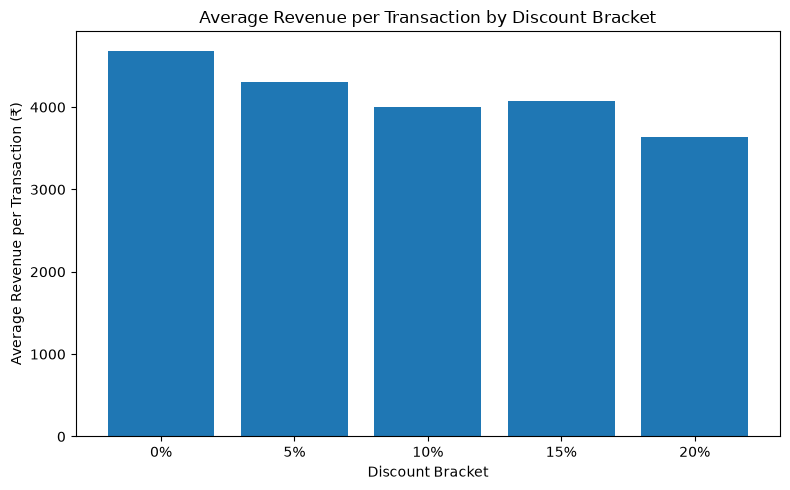

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    discount_analysis.index,
    discount_analysis["average_revenue"]
)

plt.title("Average Revenue per Transaction by Discount Bracket")
plt.xlabel("Discount Bracket")
plt.ylabel("Average Revenue per Transaction (₹)")
plt.tight_layout()
plt.show()

Business Insight

Higher discounts do not show a proportionate revenue benefit in this dataset. Average revenue per transaction falls from ₹4,686 at 0% discount to ₹3,632 at 20% discount, which is about a 22.5% decrease.

At the same time, average units sold remain almost unchanged at around 2.6 units per transaction. This means higher discounts are not leading to a meaningful increase in units sold.

Based on these results, higher discounts should be used carefully and reviewed before increasing them further. The 25%+ bracket has no transactions in this dataset.

Day of Week and Monthly Patterns

I will look at sales by day of the week and by month to understand when the chain and Electronics category perform better or worse. This can help identify suitable timings for promotions.

In [18]:
df["day"] = df["date"].dt.day_name()

daily_revenue = df.groupby(
    ["date", "day"]
)["revenue"].sum().reset_index()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_revenue = daily_revenue.groupby(
    "day"
)["revenue"].mean().reindex(day_order)

day_revenue

day
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

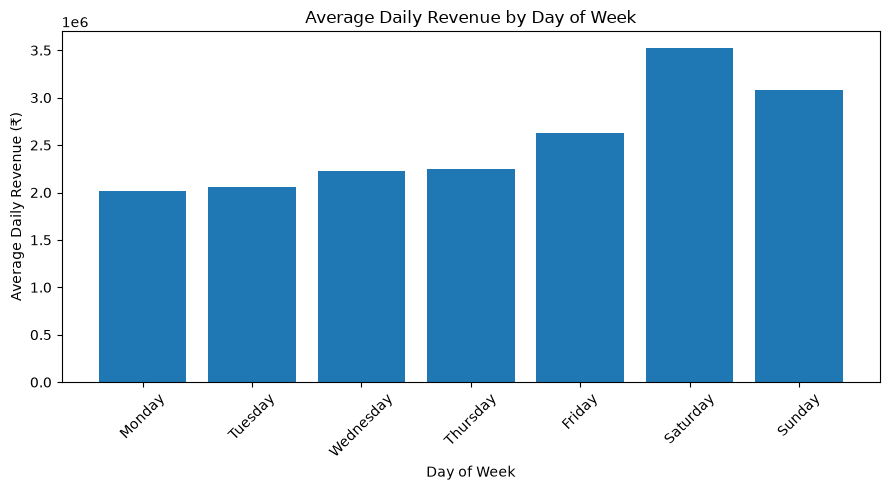

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(day_revenue.index, day_revenue.values)
plt.title("Average Daily Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
best_day = day_revenue.idxmax()
worst_day = day_revenue.idxmin()

print("Best day:", best_day)
print("Worst day:", worst_day)

Best day: Saturday
Worst day: Monday


In [21]:
monthly_chain = df.groupby("month")["revenue"].sum()
monthly_chain

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Name: revenue, dtype: float64

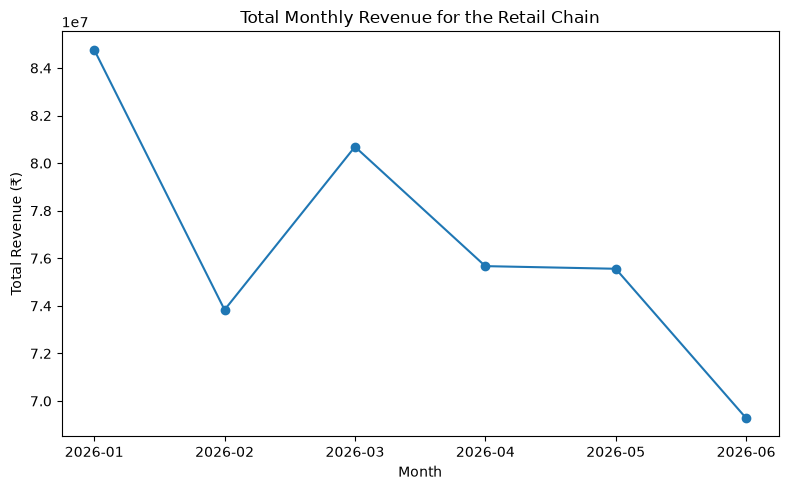

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_chain.index, monthly_chain.values, marker="o")
plt.title("Total Monthly Revenue for the Retail Chain")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.tight_layout()
plt.show()

In [23]:
best_month = monthly_chain.idxmax()
worst_month = monthly_chain.idxmin()
print("Best month:", best_month)
print("Worst month:", worst_month)

Best month: 2026-01
Worst month: 2026-06


In [24]:
electronics = df[df["category"] == "Electronics"]
electronics_daily = electronics.groupby(
    ["date", "day"]
)["revenue"].sum().reset_index()
electronics_day_revenue = electronics_daily.groupby(
    "day"
)["revenue"].mean().reindex(day_order)
electronics_day_revenue

day
Monday       9.709755e+05
Tuesday      9.754327e+05
Wednesday    1.111579e+06
Thursday     1.061518e+06
Friday       1.291064e+06
Saturday     1.786658e+06
Sunday       1.558130e+06
Name: revenue, dtype: float64

In [25]:
electronics_monthly = electronics.groupby("month")["revenue"].sum()
electronics_monthly

month
2026-01    45686596.63
2026-02    38988602.50
2026-03    40846509.47
2026-04    37092265.09
2026-05    34226926.43
2026-06    29686824.81
Name: revenue, dtype: float64

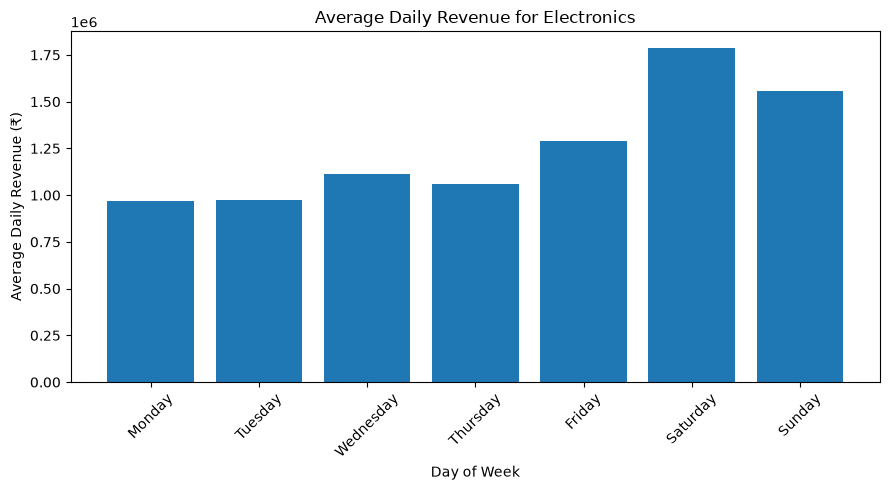

In [26]:
plt.figure(figsize=(9, 5))
plt.bar(
    electronics_day_revenue.index,
    electronics_day_revenue.values
)
plt.title("Average Daily Revenue for Electronics")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

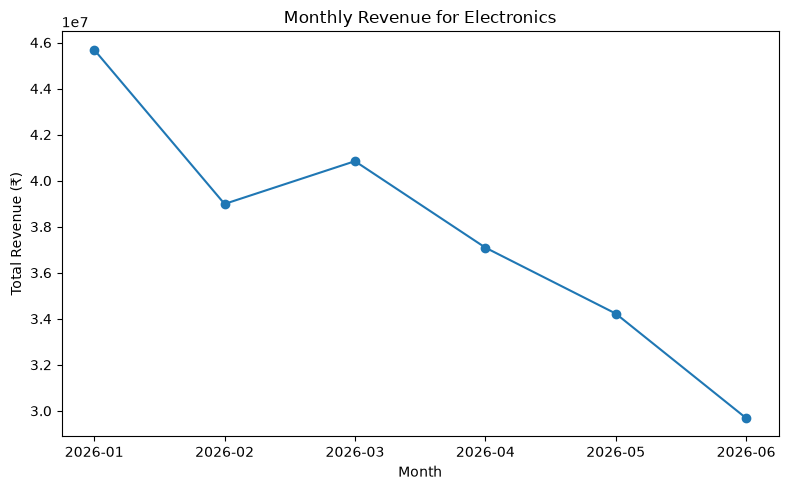

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(
    electronics_monthly.index,
    electronics_monthly.values,
    marker="o"
)
plt.title("Monthly Revenue for Electronics")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.tight_layout()
plt.show()

In [28]:
print("Electronics best day:", electronics_day_revenue.idxmax())
print("Electronics worst day:", electronics_day_revenue.idxmin())

print("Electronics best month:", electronics_monthly.idxmax())
print("Electronics worst month:", electronics_monthly.idxmin())

Electronics best day: Saturday
Electronics worst day: Monday
Electronics best month: 2026-01
Electronics worst month: 2026-06


Business Insight

For the overall retail chain, Saturday has the highest average daily revenue, at around ₹35.24 lakh, while Monday has the lowest at around ₹20.12 lakh. January is the best-performing month, with revenue of about ₹8.48 crore, whereas June has the lowest revenue at around ₹6.93 crore.

Electronics also follows a similar pattern, with Saturday performing the best and Monday the lowest. January is the strongest month for Electronics, while June is the weakest.

This shows that sales are generally higher on weekends, especially Saturdays. So, Electronics promotions can be focused more on Saturdays and other high demand periods, while less focus may be needed on Mondays.


Category Manager Briefing

Apparel has the strongest case for increased investment because its revenue grew by about 34.1% from January to June. Electronics needs attention because its revenue fell by about 35.0%, and Smart TV was the lowest-revenue Electronics product at about ₹4.19 crore over the six months. I would challenge the Electronics category supplier on the performance of Smart TV and Tablet and ask for a clear plan for improving the weaker products. Higher discounts do not show a proportionate revenue benefit, with average revenue per transaction falling from ₹4,686 at 0% discount to ₹3,632 at 20% discount while average units sold stayed around 2.6. Before making a final supplier decision, I would want supplier level performance data to connect the weaker products to specific suppliers.